# Plot scan

In [392]:
import warnings
warnings.filterwarnings("ignore", message="numpy.dtype size changed")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../')
from auxPlots import interpolateData,getContours,saveContours
pd.option_context('display.max_columns', -1)

pd.options.mode.chained_assignment = None #Disable copy warnings
# plt.style.use('fivethirtyeight') #Set style
# mpl.rcParams.update({'figure.figsize' : (15,10)})  #Set general plotting options
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})

plt.rcParams.update({"savefig.dpi" : 300}) #Figure resolution


#Define plotting style:
sns.set() #Set style
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.colormaps['RdYlBu']

#### Create txname/process translator

In [393]:
processDict = {'T2tt' : r'$\tilde{t} \, \tilde{t}, \tilde{t} \to t \chi$',
              'T2bbffff' : r'$\tilde{t} \, \tilde{t}, \tilde{t} \to b W^* \chi$',
              'T2bbWW' : r'$\tilde{t} \, \tilde{t}, \tilde{t} \to b W \chi$'}
def convertLabel(label):
    newlabel = label[:]
    #Replace txnames by process
    for txlabel,proc in processDict.items():
        newlabel = newlabel.replace(txlabel,proc) 
    #Remove off-shell Ws and Zs from ATLAS analyses (since they only appear in on-shell cases)
    if 'ATLAS' in newlabel:
        newlabel = newlabel.replace('W^{(*)} Z^{(*)}', 'W Z')
    return newlabel


In [394]:
#Merge with SModelS DataFrame
#dataDF = pd.read_pickle('sms_smodels_new.pcl')
#dataDF = pd.read_pickle('VLF_smodels.pcl')
dataDF = pd.read_pickle('Zp_ttbar_smodels.pcl')
#print(dataDF)
print(dataDF.columns.values.tolist()) #Print all columns names

['filename', 'mass.5000001', 'mass.5000511', 'mass.5000512', 'mass.5000521', 'mass.9000002', 'mass.9000003', 'mass.9000004', 'width.5000001', 'width.5000511', 'width.5000512', 'width.5000521', 'width.9000002', 'width.9000003', 'width.9000004', 'xsec13TeV(fb).5000001', 'BRs.5000001.-6,6', 'BRs.5000001.-2,2', 'BRs.5000001.-1,1', 'pars.1', 'pars.2', 'pars.3', 'pars.4', 'pars.5', 'pars.6', 'pars.7', 'pars.8', 'pars.9', 'pars.10', 'pars.11', 'pars.12', 'pars.13', 'pars.14', 'pars.15', 'pars.16', 'pars.17', 'pars.18', 'pars.19', 'pars.20', 'pars.21', 'pars.22', 'pars.23', 'pars.24', 'pars.25', 'pars.26', 'pars.27', 'pars.28', 'pars.29', 'totalxsec13TeV(fb)', 'totalxsec8TeV(fb)', 'Total xsec for missing topologies (fb)', 'Total xsec for missing topologies with displaced decays (fb)', 'Total xsec for missing topologies with prompt decays (fb)', 'Total xsec for topologies outside the grid (fb)', 'OutputStatus.sigmacut', 'OutputStatus.minmassgap', 'OutputStatus.maxcond', 'OutputStatus.ncpus', 'O

#### Set r = 0 for points with no results 

In [395]:
#Set points without results with r == 0
dataDF.fillna(value={'ExptRes.result0.r' : 0.0},inplace=True)
#Sort points according to r value:
dataDF = dataDF.sort_values(by=['ExptRes.result0.r'],ascending=False)

#### Define exclusions

In [396]:
#Add simple flag for excluded points:
newDF = dataDF.copy()
newDF['excludedLHC'] = dataDF['ExptRes.result0.r'] > 1.0/1.6

#### Add c*tau and deltaM columns

In [397]:
#newDF['ctau.5000006'] = 1.967e-16/dataDF['width.5000006']
newDF['xsecXBRtt'] = (dataDF['xsec13TeV(fb).5000001']*dataDF['BRs.5000001.-6,6']) / 1000.0
newDF['xsecXBRqq'] = (dataDF['xsec13TeV(fb).5000001']*(dataDF['BRs.5000001.-1,1'] + dataDF['BRs.5000001.-2,2'])) / 1000.0

### Get points excluded:

In [398]:
dataDF = newDF
excluded = dataDF[dataDF['excludedLHC'] == True]
allowed = dataDF[(dataDF['excludedLHC'] == False)]

print('Total number of points = %i' %len(dataDF))
print('Total excluded (LHC) = %i'%(len(excluded)))
print('Total allowed = %i\n'%(len(allowed)))

# print('Total excluded (r > %1.2f) = %i'%(rscale,len(excludedSC)))
# print('Total allowed (r > %1.2f) = %i'%(rscale,len(allowedSC)))


Total number of points = 18136
Total excluded (LHC) = 8608
Total allowed = 9528



### Split data frame by analyis/txname

In [399]:
allAnas = []
allTx = []
useDF = dataDF
anaIDcols = [c for c in useDF.columns if '.AnalysisID' in c]
txIDcols = [c for c in useDF.columns if '.TxNames' in c]
for c in anaIDcols:
    allAnas += useDF[c].values.tolist()
for c in txIDcols:
    allTx += useDF[c].values.tolist()

allAnas = [a for a in allAnas if isinstance(a,str)]
allAnas = sorted(list(set(allAnas)))
allTx = [tuple(a) for a in allTx if isinstance(a,list)]
allTx = sorted(list(set(allTx)))
anaDFs = {}
for a in allAnas:
    anaDFs[a] = {}
    newrowList = []
    for irow,row in useDF.iterrows():
        ires = [col for col in anaIDcols if (row[col] == a)]
        if not ires:
            continue
        ires = ires[0]
        ires = ires.rsplit('.',1)[0]
        newrow = { }
        for c in dataDF.columns:
            if not 'ExptRes.result' in c:
                newrow[c] = row[c]
            elif c.rsplit('.',1)[0] == ires:
                newrow[c.replace(ires,'ExptRes.result')] = row[c]
        newrowList.append(newrow)
    if len(newrowList) != 0:
        anaDFs[a] = pd.DataFrame.from_dict(newrowList)
    # for tx in allTx:
    #     newrowList = []
    #     for irow,row in useDF.iterrows():
    #         ires = [col for col in anaIDcols if ((row[col] == a)  and row[col.replace('AnalysisID','TxNames')] == list(tx))]
    #         if not ires:
    #             continue
    #         ires = min(ires).rsplit('.',1)[0]
    #         newrow = { }
    #         for c in dataDF.columns:
    #             if not 'ExptRes.result' in c:
    #                 newrow[c] = row[c]
    #             elif c.rsplit('.',1)[0] == ires:
    #                 newrow[c.replace(ires,'ExptRes.result')] = row[c]
    #         newrowList.append(newrow)
    #     if len(newrowList) != 0:
    #         anaDFs[a][tx] = pd.DataFrame.from_dict(newrowList)

### Create analysis label for excluded points

In [400]:
anas = excluded['ExptRes.result0.AnalysisID'].value_counts()
anas.sort_values(inplace=True,ascending=False)

    
labels = []
for index, row in excluded.iterrows():
    ana = row['ExptRes.result0.AnalysisID']
    txList = sorted(row['ExptRes.result0.TxNames'])
    label = ana + ' (' + ','.join(txList) + ')'
    label = label.replace('off','') #Group together on and off-shell topologies
    labels.append(label)
excluded['label'] = labels
#print(excluded['label'])


In [401]:
nexcluded = [[len(excluded[excluded['label'] == label]),label] for label in excluded['label'].unique()]
nexcluded = sorted(nexcluded,reverse=True)
nexcluded = np.array(nexcluded)
for label in nexcluded[:,1]:
    print(label+': %i'%len(excluded[excluded['label'] == label]))

CMS-EXO-19-012 (TRV1jj): 6744
ATLAS-EXOT-2019-03 (TRV1jj): 955
ATLAS-EXOT-2018-48 (TRV1tt): 909


### Define colors and plotting order

In [402]:
colors = sns.color_palette("Paired",len(excluded['label'].unique()))
colorsPink = sns.color_palette("colorblind",8)
colorDict = {'ATLAS-EXOT-2018-48 (TRV1tt)' : colorsPink[4], #light pink
             'ATLAS-EXOT-2019-03 (TRV1jj)' : 'red', #red
             'CMS-EXO-19-012 (TRV1jj)' : 'darkblue', #dark blue
             'ATLAS-SUSY-2018-12 (T2bbffff)' : 'darkgreen', #dark green
             'CMS-PAS-SUS-16-052 (T2bbWW)' : 'lightblue', #light blue
             'Other' : 'darkpurple' #dark purple
             }
#Define plotting order:
plottingOrder = nexcluded[:,1]
#Add other analyses
for ana in excluded['label'].unique():
    if not ana in plottingOrder:
        plottingOrder.append(ana)

### Plot excluded points grouped by most excluding analysis

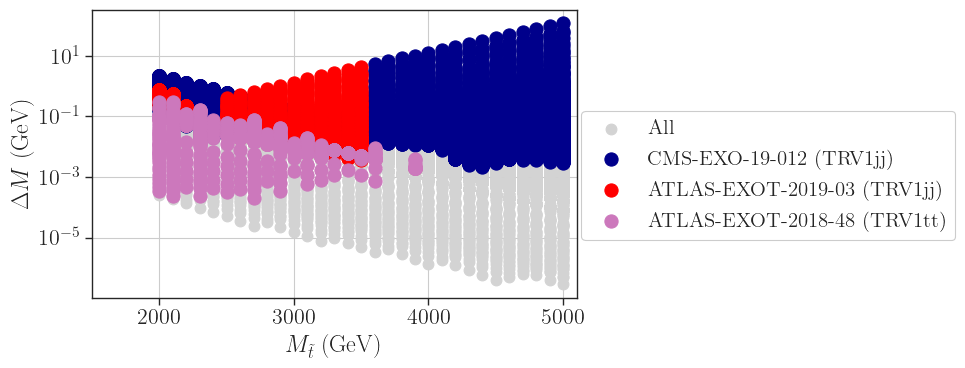

In [403]:
anas = excluded['label'].value_counts()
anas.sort_values(inplace=True,ascending=False)

plt.figure(figsize=(10,4))

x = allowed['mass.5000001']
y = allowed['xsecXBRqq']
# y = allowed['mass.5000012']
c_other = 'lightgray'
plt.scatter(x,y,color=c_other,label='All',s=60)

otherLabel = 'Others'
for ana in plottingOrder:
    x = excluded[excluded['label'] == ana]['mass.5000001']
    y = excluded[excluded['label'] == ana]['xsecXBRqq']
    if not ana in colorDict:
        color = colorDict['Other']        
        plt.scatter(x,y,color=color,label=otherLabel,s=90)
        otherLabel = None #suppress repeated label
    else:
        color = colorDict[ana]
        label = convertLabel(ana)
        plt.scatter(x,y,color=color,label=label,s=90)


lgd = plt.legend(loc=(1.01,0.2), framealpha=1.,fontsize=15)
plt.yscale('log')
plt.xlabel(r'$M_{\tilde{t}}$ (GeV)')
plt.ylabel(r'$\Delta M$ (GeV)')
plt.tight_layout()
# plt.savefig('stop_exclusion_deltaM.png')
plt.xlim(1500,5100)
# plt.ylim(0,1000)
plt.grid()
plt.show()

In [411]:
# --- Configuration ---
# Set this to 'topDom' or 'jetDom' depending on which one you want to plot
target_regime = 'topDom' 

contoursDictAna = {}

for ana in anaDFs:
    anaDF = anaDFs[ana]
    if len(anaDF[anaDF['ExptRes.result.r'] > 1.0]) == 0:
        continue

    # 1. Standard Cleaning
    cleanDF = anaDF.dropna(subset=['mass.5000001', 'xsecXBRqq']).copy()
    cleanDF['ExptRes.result.r'] = cleanDF['ExptRes.result.r'].fillna(0)
    
    # 2. CREATE FILTERS
    # A. The 1% Width Condition
    cond_width = (cleanDF['width.5000001']/cleanDF['mass.5000001'] > 0.0099) & \
                 (cleanDF['width.5000001']/cleanDF['mass.5000001'] < 0.0101)
    
    # B. The Regime Condition (Filtering by filename)
    cond_regime = cleanDF['filename'].str.contains(target_regime)
    
    # C. COMBINE THEM
    final_mask = cond_width & cond_regime
    
    # 3. Apply the combined filter
    x = cleanDF['mass.5000001'][final_mask]
    dm = cleanDF['xsecXBRqq'][final_mask]
    z = cleanDF['ExptRes.result.r'][final_mask]
    
    if len(x) < 5: # Skip if there aren't enough points to interpolate
        continue

    # 4. Interpolate (Highly recommended to use Log Space as discussed)
    dm_log = np.log10(dm)
    xnew, ynew_log, znew = interpolateData(x, dm_log, z)
    
    if xnew is None:
        continue
        
    # 5. Get Contours
    cValues = sorted([1., 1./1.5])
    # Extract in log-space for stability, then convert back to linear if needed
    cList = getContours(xnew, ynew_log, znew, cValues)
    
    if len(cList) > 0:
        contoursDictAna[ana] = cList


In [433]:
# --- Configuration ---
target_regime = 'topDom' 
# Only keep points where the top coupling is at least 20% larger than the jet coupling
dominance_margin = 1.0

# 1. Standard Cleaning
cleanDF = dataDF.dropna(subset=['mass.5000001', 'xsecXBRqq']).copy()
cleanDF['ExptRes.result0.r'] = cleanDF['ExptRes.result0.r'].fillna(0)

# Filtering the results
#  1% Width Condition
cond_width = (cleanDF['width.5000001']/cleanDF['mass.5000001'] > 0.009) & \
             (cleanDF['width.5000001']/cleanDF['mass.5000001'] < 0.011)

#  Regime Condition (Which coupling dominates)
cond_regime = cleanDF['filename'].str.contains(target_regime)

# Dominance condition
cond_threshold = cleanDF['pars.9'] > (cleanDF['pars.4'] * dominance_margin)

# Put all conditions togheter
final_mask = cond_width & cond_regime & cond_threshold

# Apply the combined filter
x = cleanDF['mass.5000001'][final_mask]
dm = cleanDF['xsecXBRqq'][final_mask]
z = cleanDF['ExptRes.result0.r'][final_mask]

# ---------------------------------------------------------
# Extract & Normalize Data
# ---------------------------------------------------------
x_raw = cleanDF['mass.5000001'][final_mask].values
y_log_raw = np.log10(cleanDF['xsecXBRqq'][final_mask].values)
z_vals = cleanDF['ExptRes.result0.r'][final_mask].values

# We scale X and Y to be between 0 and 1 so the interpolator treats them equally
x_min, x_max = x_raw.min(), x_raw.max()
y_min, y_max = y_log_raw.min(), y_log_raw.max()

x_norm = (x_raw - x_min) / (x_max - x_min)
y_norm = (y_log_raw - y_min) / (y_max - y_min)

# Create the Interpolator on scaled data
interp = LinearNDInterpolator(list(zip(x_norm, y_norm)), z_vals)

# Create the dense grid and normalize IT too
xi = np.linspace(2000, 5000, 400)
yi_log = np.linspace(-5, 0.5, 400)
X, Y_log = np.meshgrid(xi, yi_log)

X_norm = (X - x_min) / (x_max - x_min)
Y_norm = (Y_log - y_min) / (y_max - y_min)

# Apply Interpolation (Keep the nans here)
Z = interp(X_norm, Y_norm)

# ---------------------------------------------------------
#  Extract Contours & Convert to Linear
# ---------------------------------------------------------
csv_data = []


fig_tmp, ax_tmp = plt.subplots()

# Pass Z directly. The tool perfectly understands and respects NaNs.
cs = ax_tmp.contour(xi, yi_log, Z, levels=cValues)

# Loop through the contour levels (e.g., 0.67 and 1.0)
for i, cV in enumerate(cValues):
    segs = cs.allsegs[i] # Get all individual line segments for this level
    
    for poly in segs:
        # Skip tiny noise artifacts (segments with fewer than 3 points)
        if len(poly) < 3: 
            continue 
            
        # Add the points of this segment to the CSV list
        for point in poly:
            csv_data.append({
                'r_value': cV,
                'mZp_GeV': point[0],
                'xsecXBR_pb': 10**(point[1]) # Convert log-y back to linear pb here!
            })
            
        csv_data.append({
            'r_value': cV,
            'mZp_GeV': np.nan,
            'xsecXBR_pb': np.nan
        })

plt.close(fig_tmp) # Close the hidden figure

# =========================================================
# Save to CSV
# =========================================================
if csv_data:
    df_contours = pd.DataFrame(csv_data)
    csv_filename = f"Exclusion_Contours_{target_regime}_qq.csv"
    df_contours.to_csv(csv_filename, index=False)
    print(f"Successfully saved {len(df_contours)} contour points to '{csv_filename}'.")
else:
    print("No contours were found to save.")


Successfully saved 1777 contour points to 'Exclusion_Contours_topDom_qq.csv'.


5388     12.01464
1281     11.27600
18114    11.21888
14458    10.67863
5292     10.47591
           ...   
13252     0.00000
16379     0.00000
10987     0.00000
9384      0.00000
11820     0.00000
Name: ExptRes.result0.r, Length: 480, dtype: float64


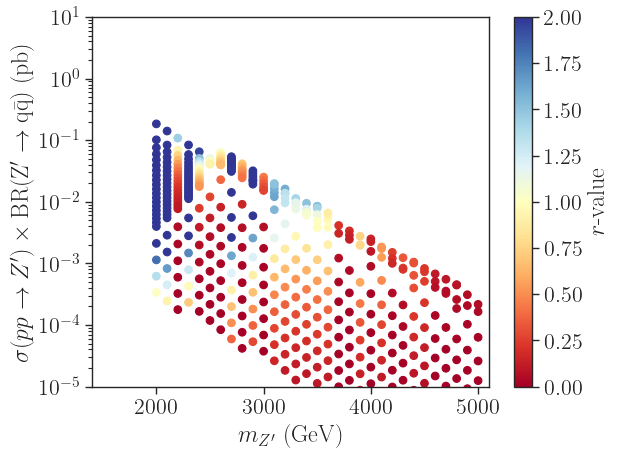

In [426]:
print(z)
plt.scatter(x,dm,c=z,cmap=cm,s=30,vmin=0.,vmax=2.)
plt.colorbar(label=r'$r$-value')
plt.xlabel(r'$m_{Z^\prime}$ (GeV)')
plt.ylabel(r'$\sigma(pp\to Z^\prime)\times\rm{BR}(Z^\prime \to q\bar{q})$ (pb)')
plt.xlim(1400.,5100.)
plt.ylim(1e-5, 10.0)
plt.yscale('log')
#plt.scatter([225.0], [70.0])
plt.show()

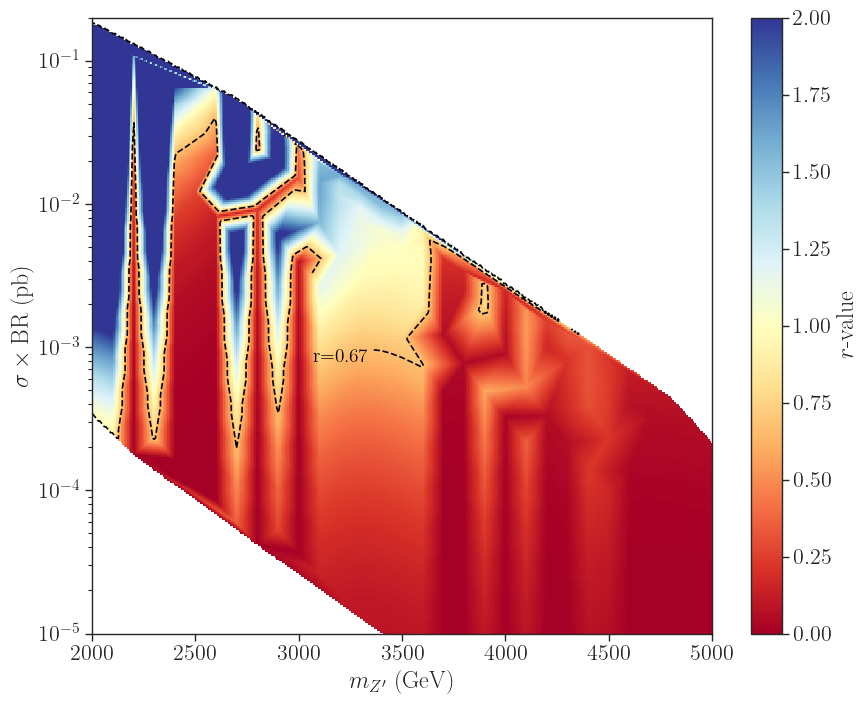

In [432]:
# ---------------------------------------------------------
# Plotting
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))
ynew_linear = 10**yi_log
cValues = sorted([ 1./1.5])
# Use 'shading=auto' to ensure sharp boundaries
mesh = plt.pcolormesh(xi, ynew_linear, Z, cmap=cm, vmin=0, vmax=2, shading='auto')
plt.colorbar(mesh, label=r'$r$-value')

# Plot the contours using the linear axes
contours = plt.contour(xi, ynew_linear, z_filled, levels=cValues, colors='black', linestyles='dashed')
plt.clabel(contours, inline=True, fontsize=14, fmt={1.0: 'r=1.0', 1./1.5: 'r=0.67'})

plt.yscale('log')
plt.xlim(2000, 5000)
plt.ylim(1e-5, 0.2)
plt.xlabel(r'$m_{Z^\prime}$ (GeV)')
plt.ylabel(r'$\sigma \times \rm{BR}$ (pb)')
#plt.title(f'Top Dominant Regime ({ana})')
plt.show()


### Save contour curves to text files

In [408]:
fname = 'SModelS_contours_Zp_qqbar.csv'
#saveContours(contoursDict,fname,header='mPsiT_GeV,deltaM_GeV')
saveContours(contoursDict,fname,header='mZp_GeV,xsecXBR_pb')


Contours saved to SModelS_contours_Zp_qqbar.csv
